# Regressao Linear via Rede Neural - SLCE3 (Dataset Indicadores)
## Analise comparativa de modelos de Machine Learning - Agro Brasil - TCC

Este notebook implementa modelos de regressao via rede neural (MLPRegressor) para prever o preco de fechamento futuro das acoes SLCE3 em diferentes horizontes temporais (3, 7, 15 e 30 dias).

**Dataset utilizado:** Dataset indicadores (OHLC + indicadores agro + indicadores tecnicos de mercado).

**Target:** Regressao continua (Close_{3,7,15,30}d_fut)

**Metodologia:** Train+Validacao (80%) + Validacao Cruzada KFold (5 folds) + Teste Final Holdout (20%), com busca de hiperparametros via RandomizedSearchCV.


### Importacao das bibliotecas e carregamento do dataset


In [1]:
import pandas as pd
import numpy as np
from typing import cast

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, cross_val_predict
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore')

# Configuracao para salvar graficos
OUTPUT_DIR = './'
os.makedirs(OUTPUT_DIR, exist_ok=True)

COMPANY = 'SLCE3'
DATASET_LABEL = 'indicadores'
DATASET_NAME = 'Indicadores'
company_lower = COMPANY.lower()

# Carrega o dataset tratado para regressao
df = pd.read_csv('../../../../datasets/datasets_indicadores/regressao/SLCE3_tratado.csv')

print('='*60)
print(f'DATASET {COMPANY} - REGRESSAO LINEAR VIA REDE NEURAL ({DATASET_LABEL.upper()})')
print('='*60)
print(f'\nShape: {df.shape}')
print('\nColunas disponiveis:')
print(df.columns.tolist())
print('\nPrimeiras 5 linhas do DataFrame:')
print(df.head())

print('\nInformacoes gerais do DataFrame:')
print(df.info())

print('\nEstatisticas descritivas:')
print(df.describe())

print('\nImputacao de ausentes sera feita DENTRO do Pipeline (SimpleImputer), apos o split.')


DATASET SLCE3 - REGRESSAO LINEAR VIA REDE NEURAL (INDICADORES)

Shape: (1633, 25)

Colunas disponiveis:
['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'agro_soja_close_lag_1d', 'agro_soja_close_lag_3d', 'agro_soja_close_lag_6d', 'agro_soja_close_lag_10d', 'agro_cambio_close_lag_1d', 'agro_cambio_close_lag_3d', 'agro_cambio_close_lag_6d', 'agro_cambio_close_lag_10d', 'Close_3d_fut', 'Close_7d_fut', 'Close_15d_fut', 'Close_30d_fut', 'OBV', 'FWMA', 'TEMA', 'HLC3', 'BB_upper', 'BB_middle', 'BB_lower']

Primeiras 5 linhas do DataFrame:
         Date     Close      High       Low      Open   Volume  \
0  2018-02-15  3.729142  3.812630  3.721349  3.807064  8115228   
1  2018-02-16  3.704652  3.771443  3.682388  3.751405  1686256   
2  2018-02-20  3.740273  3.773669  3.695747  3.706878   897336   
3  2018-02-21  3.677936  3.789253  3.677936  3.741386  1346972   
4  2018-02-22  3.697973  3.799272  3.623390  3.702426  1547832   

   agro_soja_close_lag_1d  agro_soja_close_lag_3d  agro_soja_c

### Preparacao dos dados para modelagem


In [2]:
# Definir features: base (OHLC) + indicadores agro (lags) + extras
base_features = ['Close', 'Low', 'High', 'Open']
agro_lag_features = ['agro_cambio_close_lag_1d', 'agro_cambio_close_lag_3d', 'agro_cambio_close_lag_6d', 'agro_cambio_close_lag_10d', 'agro_soja_close_lag_1d', 'agro_soja_close_lag_3d', 'agro_soja_close_lag_6d', 'agro_soja_close_lag_10d']
technical_indicators = ['OBV', 'FWMA', 'TEMA', 'HLC3', 'BB_upper', 'BB_middle', 'BB_lower']
all_features = base_features + agro_lag_features + technical_indicators

X = df[all_features].copy()

# Definir targets (variaveis dependentes) - janelas temporais
targets = {
    '3d': df['Close_3d_fut'],
    '7d': df['Close_7d_fut'],
    '15d': df['Close_15d_fut'],
    '30d': df['Close_30d_fut']
}

print('Variaveis independentes (X):')
print(X.columns.tolist())
print(f'\nShape de X: {X.shape}')
print(f'\nComposicao de features:')
print(f'  - Base features ({len(base_features)}): {base_features}')
print(f'  - Indicadores agro ({len(agro_lag_features)}): {agro_lag_features}')
print(f'  - technical_indicators ({len(technical_indicators)}): {technical_indicators}')
print(f'  - Total: {len(all_features)} features')

print('\nTargets (regressao - preco futuro):')
for name, target in targets.items():
    print(f'  - {name}: {target.name}')


Variaveis independentes (X):
['Close', 'Low', 'High', 'Open', 'agro_cambio_close_lag_1d', 'agro_cambio_close_lag_3d', 'agro_cambio_close_lag_6d', 'agro_cambio_close_lag_10d', 'agro_soja_close_lag_1d', 'agro_soja_close_lag_3d', 'agro_soja_close_lag_6d', 'agro_soja_close_lag_10d', 'OBV', 'FWMA', 'TEMA', 'HLC3', 'BB_upper', 'BB_middle', 'BB_lower']

Shape de X: (1633, 19)

Composicao de features:
  - Base features (4): ['Close', 'Low', 'High', 'Open']
  - Indicadores agro (8): ['agro_cambio_close_lag_1d', 'agro_cambio_close_lag_3d', 'agro_cambio_close_lag_6d', 'agro_cambio_close_lag_10d', 'agro_soja_close_lag_1d', 'agro_soja_close_lag_3d', 'agro_soja_close_lag_6d', 'agro_soja_close_lag_10d']
  - technical_indicators (7): ['OBV', 'FWMA', 'TEMA', 'HLC3', 'BB_upper', 'BB_middle', 'BB_lower']
  - Total: 19 features

Targets (regressao - preco futuro):
  - 3d: Close_3d_fut
  - 7d: Close_7d_fut
  - 15d: Close_15d_fut
  - 30d: Close_30d_fut


In [3]:
# Definir CV para regressao: 5 folds
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

# Espaco de hiperparametros para busca aleatoria do MLP
param_dist = {
    'model__hidden_layer_sizes': [(32,), (64,), (64, 32), (128, 64)],
    'model__activation': ['relu', 'tanh'],
    'model__alpha': [1e-5, 1e-4, 1e-3, 1e-2],
    'model__learning_rate_init': [1e-4, 5e-4, 1e-3, 5e-3],
    'model__solver': ['adam', 'lbfgs']
}

print('='*60)
print('CONFIGURACAO DA VALIDACAO CRUZADA')
print('='*60)
print('\nEstrategia CV: KFold')
print('  - N splits (folds): 5')
print('  - Shuffle: True')
print('  - Random state: 42')

print('\nEspaco de hiperparametros (MLPRegressor dentro do Pipeline):')
print(f"  - hidden_layer_sizes: {param_dist['model__hidden_layer_sizes']}")
print(f"  - activation: {param_dist['model__activation']}")
print(f"  - alpha: {param_dist['model__alpha']}")
print(f"  - learning_rate_init: {param_dist['model__learning_rate_init']}")
print(f"  - solver: {param_dist['model__solver']}")

print('\nScoring metric: neg_mean_absolute_error (foco em erro absoluto menor)')

print('\n' + '='*70)
print('DIAGNOSTICO DOS TARGETS POR HORIZONTE')
print('='*70)
for period, y in targets.items():
    y_clean = y.dropna()
    print(f"\nHorizonte {period.upper()}")
    print(f"  - Amostras: {y_clean.shape[0]}")
    print(f"  - Media: {y_clean.mean():.4f}")
    print(f"  - Desvio padrao: {y_clean.std():.4f}")
    print(f"  - Min: {y_clean.min():.4f} | Max: {y_clean.max():.4f}")


CONFIGURACAO DA VALIDACAO CRUZADA

Estrategia CV: KFold
  - N splits (folds): 5
  - Shuffle: True
  - Random state: 42

Espaco de hiperparametros (MLPRegressor dentro do Pipeline):
  - hidden_layer_sizes: [(32,), (64,), (64, 32), (128, 64)]
  - activation: ['relu', 'tanh']
  - alpha: [1e-05, 0.0001, 0.001, 0.01]
  - learning_rate_init: [0.0001, 0.0005, 0.001, 0.005]
  - solver: ['adam', 'lbfgs']

Scoring metric: neg_mean_absolute_error (foco em erro absoluto menor)

DIAGNOSTICO DOS TARGETS POR HORIZONTE

Horizonte 3D
  - Amostras: 1633
  - Media: 12.9541
  - Desvio padrao: 5.2328
  - Min: 3.6779 | Max: 22.6680

Horizonte 7D
  - Amostras: 1633
  - Media: 12.9851
  - Desvio padrao: 5.2157
  - Min: 3.7547 | Max: 22.6680

Horizonte 15D
  - Amostras: 1633
  - Media: 13.0510
  - Desvio padrao: 5.1856
  - Min: 3.7547 | Max: 22.6680

Horizonte 30D
  - Amostras: 1633
  - Media: 13.1800
  - Desvio padrao: 5.1330
  - Min: 3.7770 | Max: 22.6680


### Configuracao da Validacao Cruzada


### Treinamento dos Modelos de Regressao via Rede Neural com RandomizedSearchCV


In [4]:
print('TREINAMENTO REGRESSAO LINEAR VIA REDE NEURAL - SLCE3 (COM VALIDACAO CRUZADA)')
print('='*60)

models = {}
search_results = {}

for period, y in targets.items():
    print(f'\n\n{"="*60}')
    print(f'PERIODO: {period.upper()}')
    print(f'{"="*60}')

    # Remover NaN do target
    mask = ~y.isnull()
    X_clean = X.loc[mask].copy()
    y_clean = y.loc[mask].copy()

    print('\n1. SEPARACAO INICIAL (Train+Val vs Teste Final)')
    print(f'   Dados elegiveis: {X_clean.shape[0]} amostras')

    # Step 1: Separar teste final (holdout)
    X_dev, X_test, y_dev, y_test = train_test_split(
        X_clean, y_clean, test_size=0.2, random_state=42, shuffle=True
    )

    print(f'   - Desenvolvimento (Train+Val): {X_dev.shape[0]} amostras')
    print(f'   - Teste Final (Holdout): {X_test.shape[0]} amostras')

    print('\n2. BUSCA DE HIPERPARAMETROS (RandomizedSearchCV + KFold)')

    # Step 2: Pipeline com imputacao + escala + MLP para evitar leakage
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', MLPRegressor(
            max_iter=1500,
            random_state=42
        ))
    ])

    # Step 3: RandomizedSearchCV com KFold
    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_dist,
        n_iter=5,
        scoring='neg_mean_absolute_error',
        cv=cv_strategy,
        n_jobs=-1,
        random_state=42,
        verbose=0
    )

    print('   - N iteracoes (combinacoes aleatorias): 12')
    print('   - CV folds: 5')
    print('   - Metrica de selecao: neg_mean_absolute_error')
    print('   - Treinando...')

    random_search.fit(X_dev, y_dev)

    best_pipeline = cast(Pipeline, random_search.best_estimator_)
    best_params = random_search.best_params_
    best_cv_mae = -random_search.best_score_

    print('\n   OK - Busca concluida!')
    print(f'   - Melhor MAE (CV): {best_cv_mae:.4f}')
    print('   - Melhores parametros:')
    for param, value in sorted(best_params.items()):
        print(f'       {param}: {value}')

    print('\n3. AVALIACAO DE VALIDACAO (OOF no Dev)')
    oof_pred = cross_val_predict(
        best_pipeline, X_dev, y_dev, cv=cv_strategy, method='predict', n_jobs=-1
    )

    val_r2 = r2_score(y_dev, oof_pred)
    val_mae = mean_absolute_error(y_dev, oof_pred)
    val_rmse = float(np.sqrt(mean_squared_error(y_dev, oof_pred)))

    print(f'   - OOF R2: {val_r2:.4f}')
    print(f'   - OOF MAE: {val_mae:.4f}')
    print(f'   - OOF RMSE: {val_rmse:.4f}')

    print('\n4. AVALIACAO NO TESTE FINAL (holdout)')

    # Refit final no conjunto de desenvolvimento completo e avaliacao no teste
    best_pipeline.fit(X_dev, y_dev)
    y_pred = best_pipeline.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = float(np.sqrt(mse))

    mlp_model = best_pipeline.named_steps['model']

    print('   Metricas no Teste Final (20%):')
    print(f'   - R2: {r2:.4f}')
    print(f'   - MAE: {mae:.4f}')
    print(f'   - RMSE: {rmse:.4f}')
    print(f'   - N iteracoes ate convergencia: {mlp_model.n_iter_}')
    print(f'   - Loss final: {getattr(mlp_model, "loss_", float("nan")):.6f}')

    models[period] = {
        'model': best_pipeline,
        'best_params': best_params,
        'best_cv_mae': best_cv_mae,
        'val_r2_oof': val_r2,
        'val_mae_oof': val_mae,
        'val_rmse_oof': val_rmse,
        'r2': r2,
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'X_train': X_dev,
        'X_test': X_test,
        'y_train': y_dev,
        'y_test': y_test,
        'y_pred': y_pred,
        'oof_pred': oof_pred,
        'search_object': random_search
    }

    search_results[period] = {
        'best_cv_mae': best_cv_mae,
        'best_params': best_params,
        'oof_r2': val_r2,
        'oof_mae': val_mae,
        'test_r2': r2,
        'test_mae': mae,
        'test_rmse': rmse
    }

print('\n' + '='*60)
print('OK - 4 modelos treinados com validacao cruzada e holdout final!')
print('='*60)


TREINAMENTO REGRESSAO LINEAR VIA REDE NEURAL - SLCE3 (COM VALIDACAO CRUZADA)


PERIODO: 3D

1. SEPARACAO INICIAL (Train+Val vs Teste Final)
   Dados elegiveis: 1633 amostras
   - Desenvolvimento (Train+Val): 1306 amostras
   - Teste Final (Holdout): 327 amostras

2. BUSCA DE HIPERPARAMETROS (RandomizedSearchCV + KFold)
   - N iteracoes (combinacoes aleatorias): 12
   - CV folds: 5
   - Metrica de selecao: neg_mean_absolute_error
   - Treinando...

   OK - Busca concluida!
   - Melhor MAE (CV): 0.3434
   - Melhores parametros:
       model__activation: relu
       model__alpha: 0.01
       model__hidden_layer_sizes: (64, 32)
       model__learning_rate_init: 0.001
       model__solver: lbfgs

3. AVALIACAO DE VALIDACAO (OOF no Dev)
   - OOF R2: 0.9915
   - OOF MAE: 0.3434
   - OOF RMSE: 0.4794

4. AVALIACAO NO TESTE FINAL (holdout)
   Metricas no Teste Final (20%):
   - R2: 0.9936
   - MAE: 0.3089
   - RMSE: 0.4253
   - N iteracoes ate convergencia: 1500
   - Loss final: 0.031100


PERIO

### Tabela Resumo das Metricas


In [5]:
# Criar DataFrame com resumo das metricas
metrics_summary = pd.DataFrame({
    'Horizonte': ['3 dias', '7 dias', '15 dias', '30 dias'],
    'CV MAE': [models['3d']['best_cv_mae'], models['7d']['best_cv_mae'],
               models['15d']['best_cv_mae'], models['30d']['best_cv_mae']],
    'OOF R2': [models['3d']['val_r2_oof'], models['7d']['val_r2_oof'],
               models['15d']['val_r2_oof'], models['30d']['val_r2_oof']],
    'OOF MAE': [models['3d']['val_mae_oof'], models['7d']['val_mae_oof'],
                models['15d']['val_mae_oof'], models['30d']['val_mae_oof']],
    'Test R2': [models['3d']['r2'], models['7d']['r2'], models['15d']['r2'], models['30d']['r2']],
    'Test MAE': [models['3d']['mae'], models['7d']['mae'], models['15d']['mae'], models['30d']['mae']],
    'Test RMSE': [models['3d']['rmse'], models['7d']['rmse'], models['15d']['rmse'], models['30d']['rmse']]
})

print('\nRESUMO DAS METRICAS - SLCE3 (INDICADORES)')
print('='*120)
print(metrics_summary.to_string(index=False))
print('\nLegenda:')
print('  - CV MAE: MAE medio da validacao cruzada (5 folds) no RandomizedSearchCV')
print('  - OOF *: metricas out-of-fold no conjunto de desenvolvimento')
print('  - Test *: metricas no teste final (20% holdout)')

# Salvar metricas em CSV
metrics_summary.to_csv(f'{OUTPUT_DIR}metricas_{company_lower}_{DATASET_LABEL}.csv', index=False)
print(f'\nOK - Metricas salvas em metricas_{company_lower}_{DATASET_LABEL}.csv')



RESUMO DAS METRICAS - SLCE3 (INDICADORES)
Horizonte   CV MAE   OOF R2  OOF MAE  Test R2  Test MAE  Test RMSE
   3 dias 0.343433 0.991526 0.343429 0.993560  0.308898   0.425341
   7 dias 0.345302 0.991818 0.345291 0.993698  0.311958   0.421128
  15 dias 0.366218 0.990819 0.366203 0.993062  0.321310   0.436356
  30 dias 0.377578 0.989602 0.377577 0.992089  0.359158   0.465419

Legenda:
  - CV MAE: MAE medio da validacao cruzada (5 folds) no RandomizedSearchCV
  - OOF *: metricas out-of-fold no conjunto de desenvolvimento
  - Test *: metricas no teste final (20% holdout)

OK - Metricas salvas em metricas_slce3_indicadores.csv


---
# Analises Graficas


### Graficos de Serie Temporal - Real vs Predito


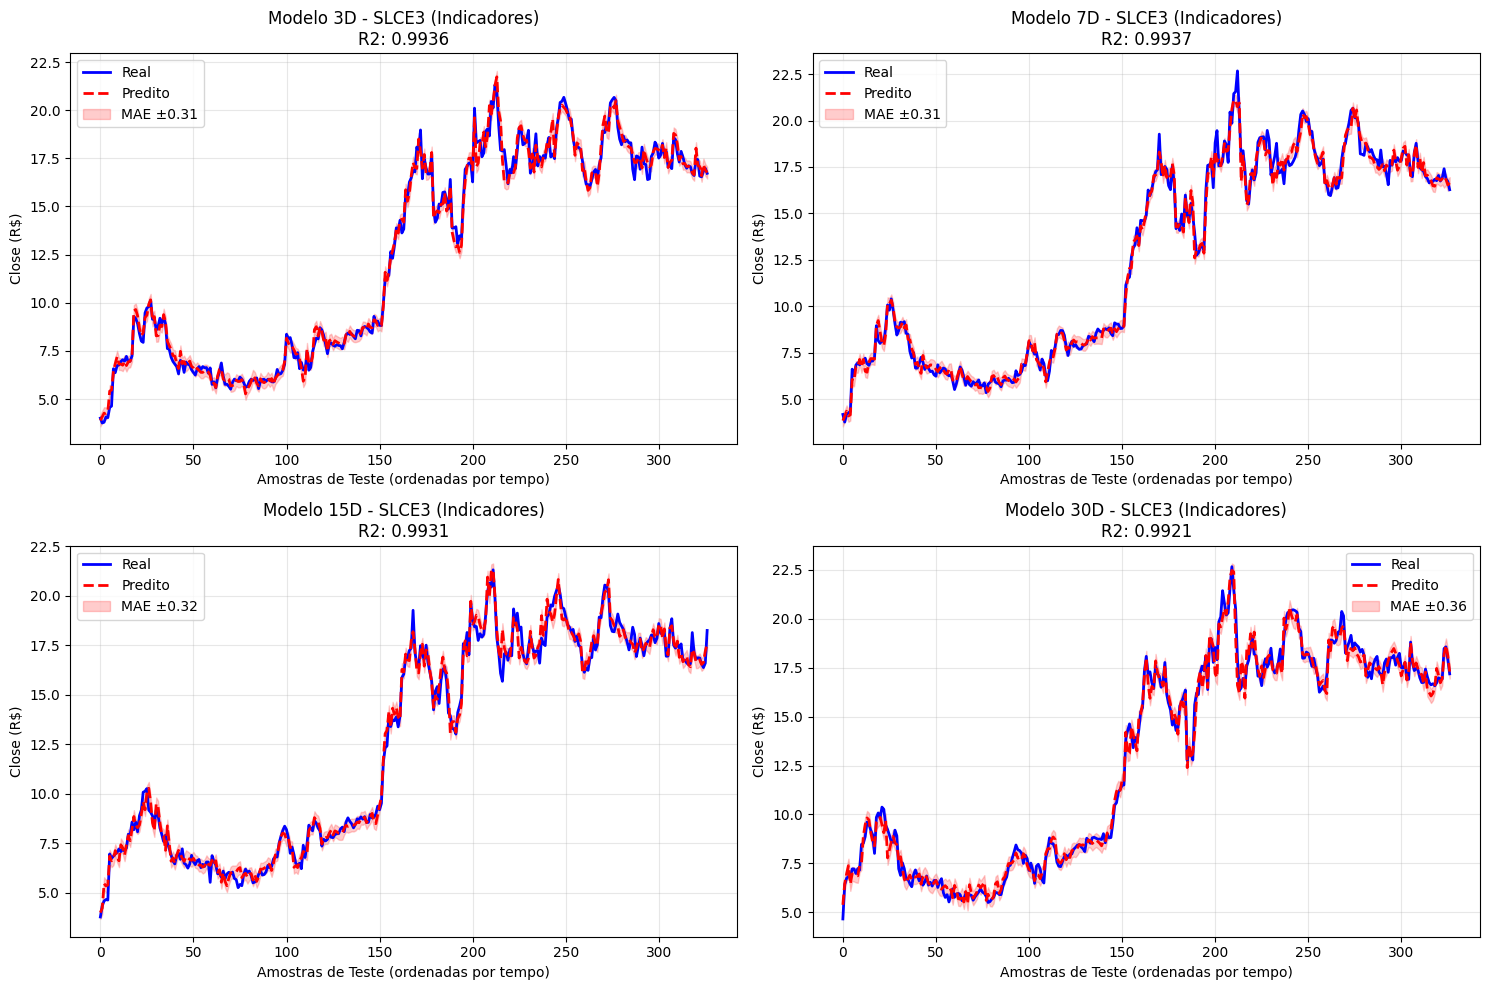

OK - Grafico de serie temporal salvo


In [6]:
# Graficos de serie temporal
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    mae = model_data['mae']

    # Ordenar por indice para visualizacao temporal
    test_indices = model_data['X_test'].index
    sorted_indices = sorted(range(len(test_indices)), key=lambda i: test_indices[i])

    y_test_sorted = y_test.iloc[sorted_indices]
    y_pred_sorted = y_pred[sorted_indices]

    ax = axes[idx]
    ax.plot(range(len(y_test_sorted)), y_test_sorted, 'b-', label='Real', linewidth=2)
    ax.plot(range(len(y_pred_sorted)), y_pred_sorted, 'r--', label='Predito', linewidth=2)

    # Tunel do MAE
    ax.fill_between(range(len(y_pred_sorted)),
                    y_pred_sorted - mae,
                    y_pred_sorted + mae,
                    alpha=0.2, color='red', label=f'MAE ±{mae:.2f}')

    ax.set_title(f'Modelo {period.upper()} - SLCE3 (Indicadores)\nR2: {model_data["r2"]:.4f}')
    ax.set_xlabel('Amostras de Teste (ordenadas por tempo)')
    ax.set_ylabel('Close (R$)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}serie_temporal_{company_lower}_{DATASET_LABEL}.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Grafico de serie temporal salvo')


### Graficos de Residuos


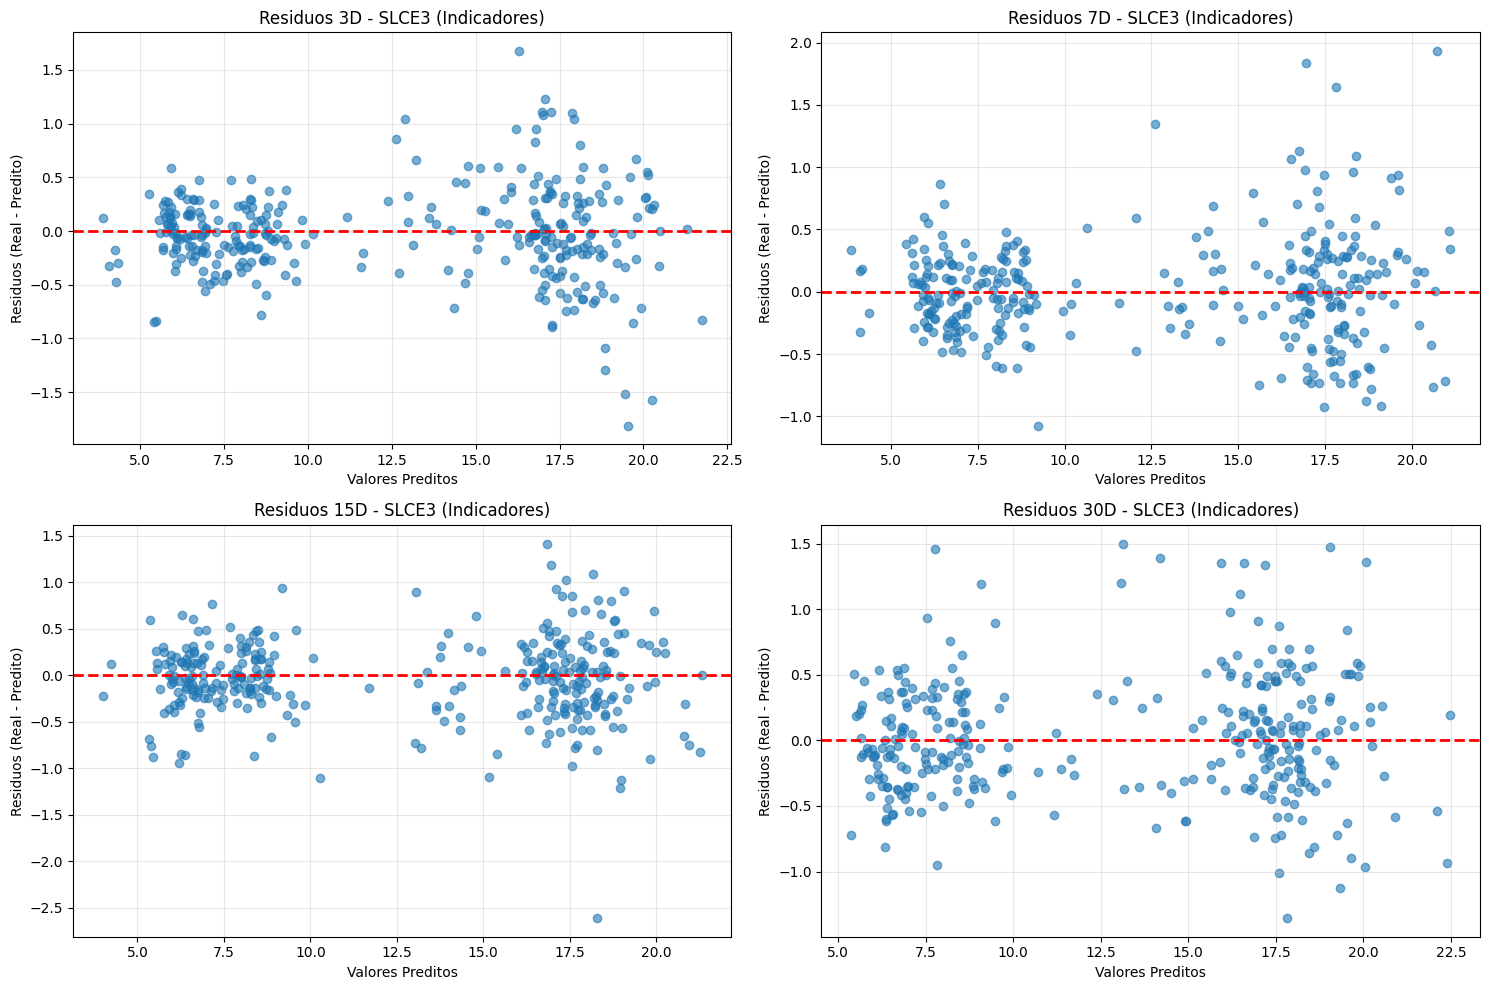

OK - Grafico de residuos salvo


In [7]:
# Graficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    residuos = y_test - y_pred

    ax = axes[idx]
    ax.scatter(y_pred, residuos, alpha=0.6)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'Residuos {period.upper()} - SLCE3 (Indicadores)')
    ax.set_xlabel('Valores Preditos')
    ax.set_ylabel('Residuos (Real - Predito)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}residuos_{company_lower}_{DATASET_LABEL}.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Grafico de residuos salvo')


### Graficos Real vs Predito


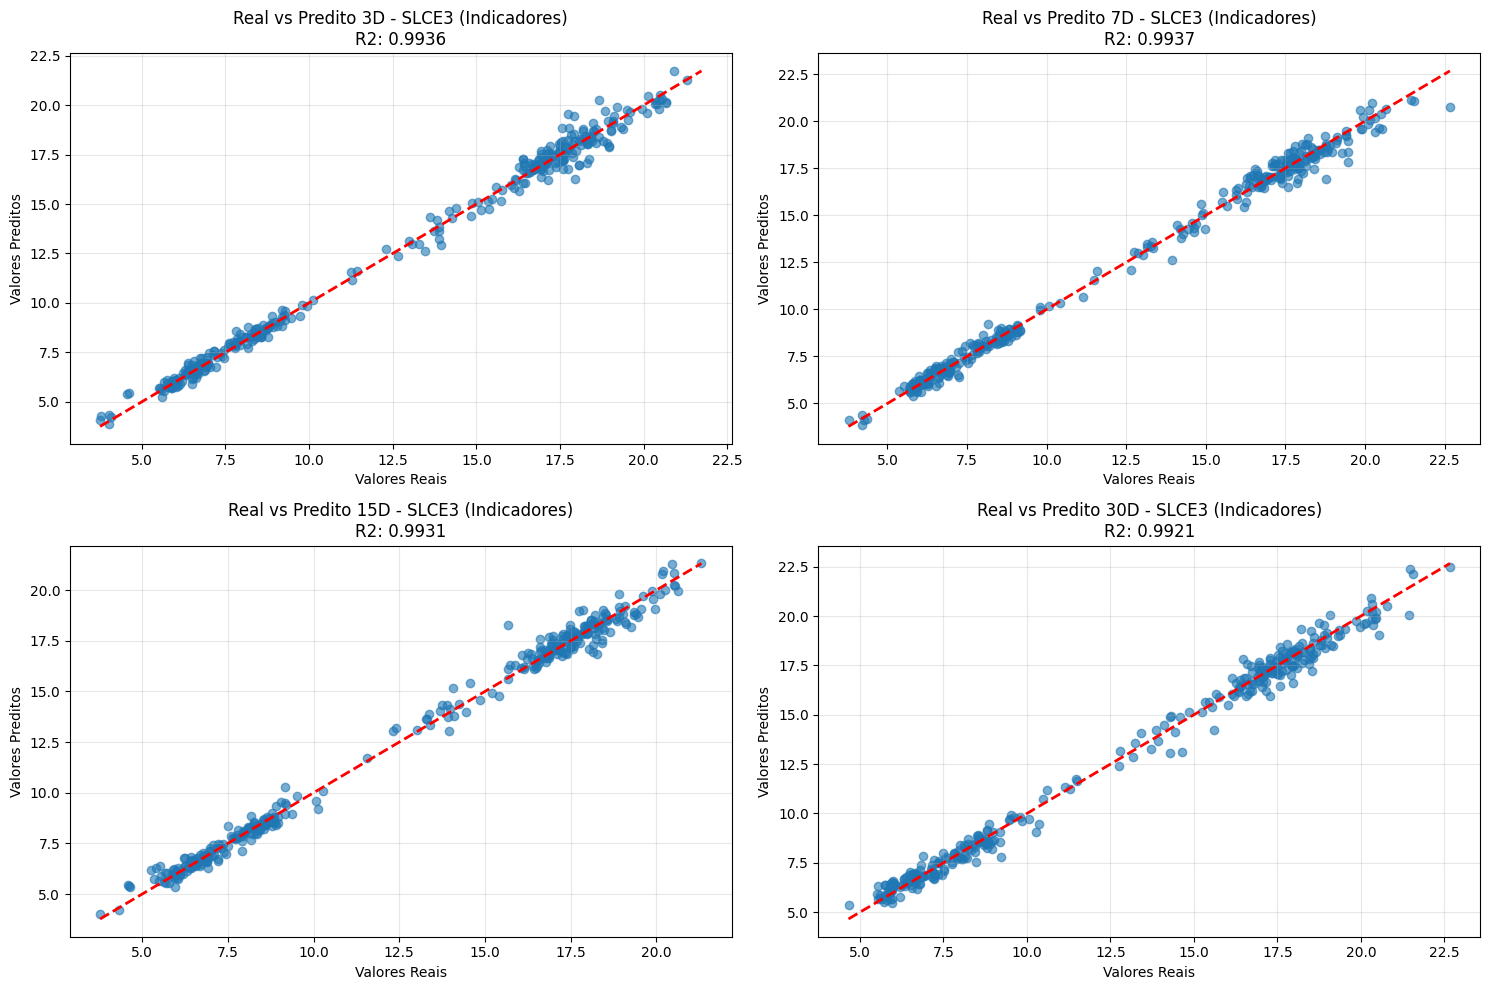

OK - Grafico real vs predito salvo


In [8]:
# Graficos Real vs Predito
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']

    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.6)

    # Linha diagonal y=x (predicao perfeita)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

    ax.set_title(f'Real vs Predito {period.upper()} - SLCE3 (Indicadores)\nR2: {model_data["r2"]:.4f}')
    ax.set_xlabel('Valores Reais')
    ax.set_ylabel('Valores Preditos')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}real_vs_predito_{company_lower}_{DATASET_LABEL}.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Grafico real vs predito salvo')


### Comparacao das Metricas (CV vs Teste)


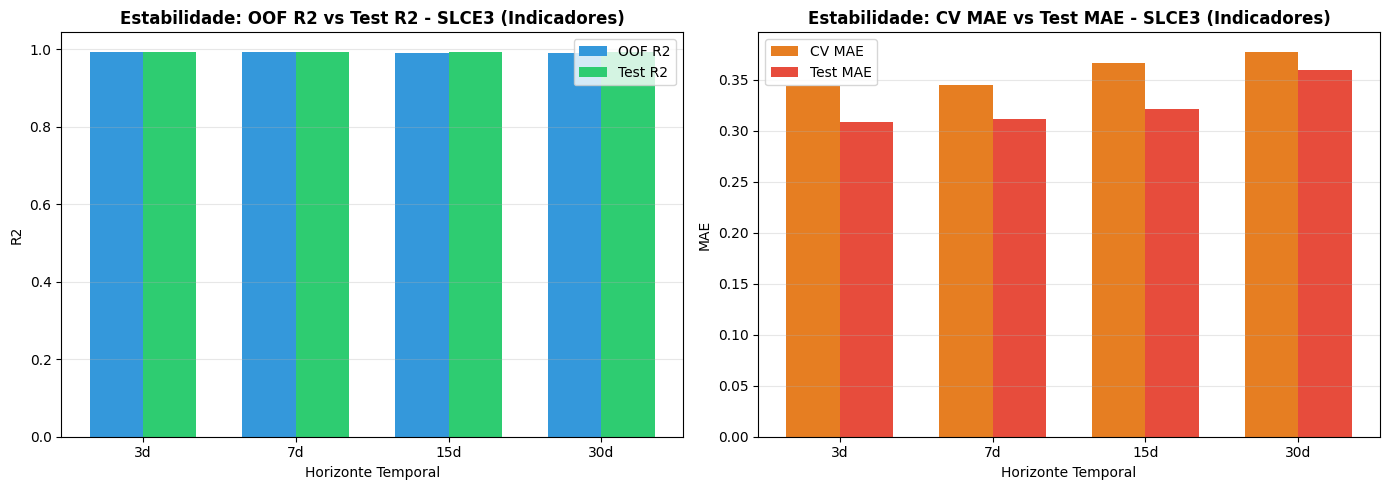

OK - Grafico de comparacao CV vs Teste salvo


In [9]:
# Comparacao CV vs Teste para R2 e MAE
periods = ['3d', '7d', '15d', '30d']
cv_mae_values = [models[p]['best_cv_mae'] for p in periods]
oof_r2_values = [models[p]['val_r2_oof'] for p in periods]
test_r2_values = [models[p]['r2'] for p in periods]
test_mae_values = [models[p]['mae'] for p in periods]

# Compatibilidade com celulas seguintes
r2_values = test_r2_values
mae_values = test_mae_values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(periods))
width = 0.35

# R2 OOF vs Test
ax1.bar(x - width/2, oof_r2_values, width, label='OOF R2', color='#3498db')
ax1.bar(x + width/2, test_r2_values, width, label='Test R2', color='#2ecc71')
ax1.set_xlabel('Horizonte Temporal')
ax1.set_ylabel('R2')
ax1.set_title('Estabilidade: OOF R2 vs Test R2 - SLCE3 (Indicadores)', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(periods)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# MAE CV vs Test
ax2.bar(x - width/2, cv_mae_values, width, label='CV MAE', color='#e67e22')
ax2.bar(x + width/2, test_mae_values, width, label='Test MAE', color='#e74c3c')
ax2.set_xlabel('Horizonte Temporal')
ax2.set_ylabel('MAE')
ax2.set_title('Estabilidade: CV MAE vs Test MAE - SLCE3 (Indicadores)', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(periods)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}comparacao_cv_vs_teste_{company_lower}_{DATASET_LABEL}.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Grafico de comparacao CV vs Teste salvo')


### Histogramas dos Residuos


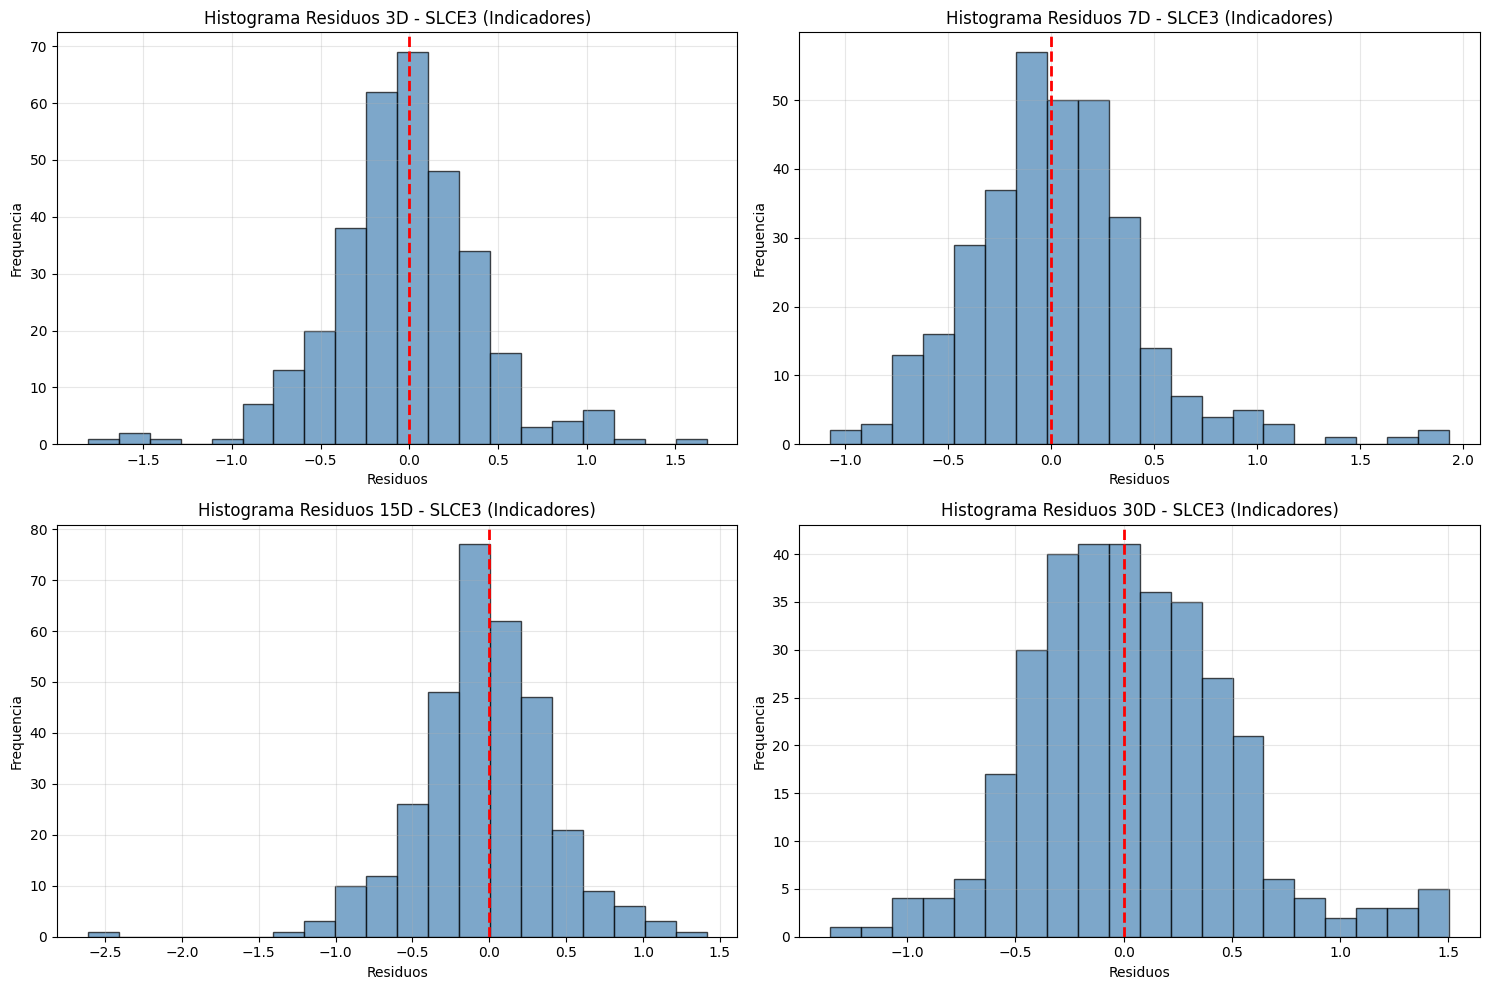

OK - Histograma de residuos salvo


In [10]:
# Histogramas dos residuos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    residuos = y_test - y_pred

    ax = axes[idx]
    ax.hist(residuos, bins=20, alpha=0.7, edgecolor='black', color='steelblue')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'Histograma Residuos {period.upper()} - SLCE3 (Indicadores)')
    ax.set_xlabel('Residuos')
    ax.set_ylabel('Frequencia')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}histograma_residuos_{company_lower}_{DATASET_LABEL}.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Histograma de residuos salvo')


### Residuos vs Ordem Temporal


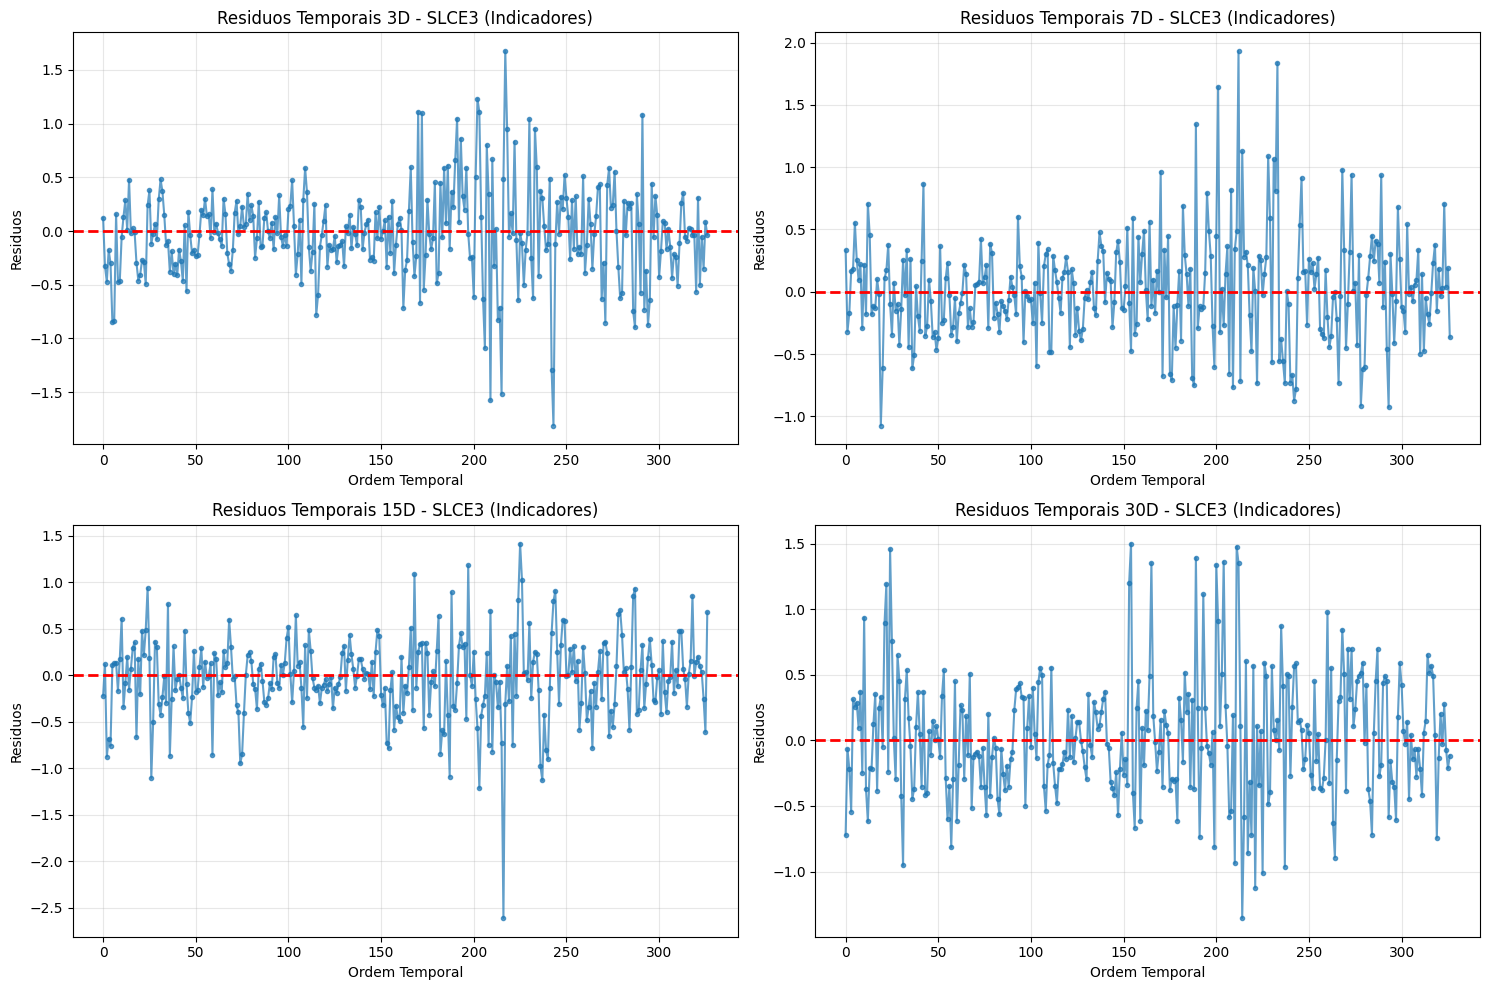

OK - Grafico de residuos temporais salvo


In [11]:
# Residuos vs Ordem Temporal
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    residuos = y_test - y_pred

    # Ordenar por indice temporal
    test_indices = model_data['X_test'].index
    sorted_indices = sorted(range(len(test_indices)), key=lambda i: test_indices[i])
    residuos_sorted = residuos.iloc[sorted_indices]

    ax = axes[idx]
    ax.plot(range(len(residuos_sorted)), residuos_sorted, 'o-', markersize=3, alpha=0.7)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'Residuos Temporais {period.upper()} - SLCE3 (Indicadores)')
    ax.set_xlabel('Ordem Temporal')
    ax.set_ylabel('Residuos')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}residuos_temporais_{company_lower}_{DATASET_LABEL}.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Grafico de residuos temporais salvo')


### Grafico de Dispersao com Intervalo de Confianca (IC 95%)


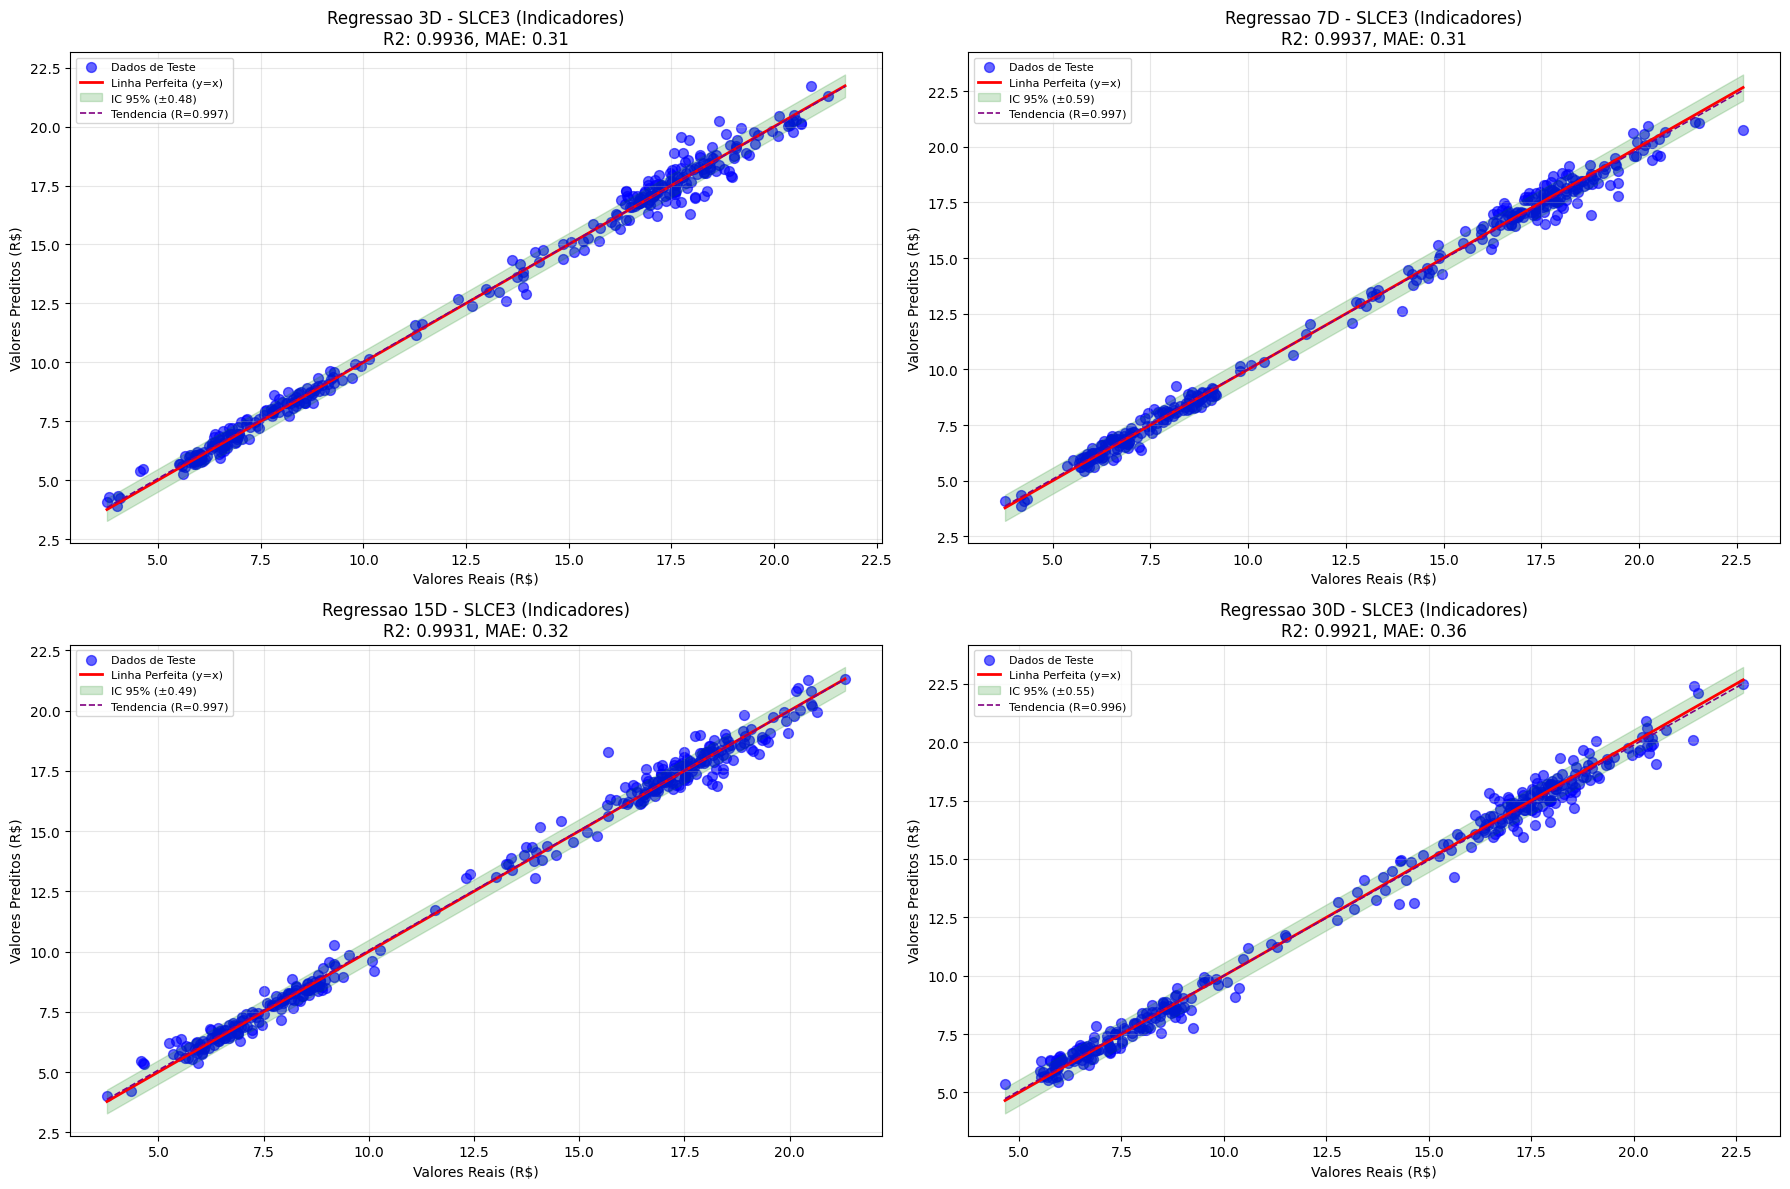

OK - Grafico de dispersao com IC 95% salvo


In [12]:
# Graficos de dispersao com linha de regressao e IC 95%
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    y_train = model_data['y_train']
    y_pred_train = model_data['model'].predict(model_data['X_train'])

    # Calcular MSE e desvio padrao dos residuos (sobre treino)
    mse_train = mean_squared_error(y_train, y_pred_train)
    residual_std = float(np.sqrt(mse_train))

    ax = axes[idx]

    # Scatter dos dados de teste
    ax.scatter(y_test, y_pred, alpha=0.6, color='blue', s=50, label='Dados de Teste')

    # Linha y = x
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    line_vals = np.linspace(min_val, max_val, 100)
    ax.plot(line_vals, line_vals, 'r-', linewidth=2, label='Linha Perfeita (y=x)')

    # Intervalo de confianca 95%
    confidence_interval = 1.96 * residual_std
    ax.fill_between(line_vals,
                    line_vals - confidence_interval,
                    line_vals + confidence_interval,
                    alpha=0.18, color='green',
                    label=f'IC 95% (±{confidence_interval:.2f})')

    # Linha de tendencia
    slope, intercept, r_value, p_value, std_err = stats.linregress(y_test, y_pred)
    regression_line = slope * line_vals + intercept
    ax.plot(line_vals, regression_line, '--', color='purple', linewidth=1.2, label=f'Tendencia (R={r_value:.3f})')

    ax.set_title(f'Regressao {period.upper()} - SLCE3 (Indicadores)\nR2: {model_data["r2"]:.4f}, MAE: {model_data["mae"]:.2f}')
    ax.set_xlabel('Valores Reais (R$)')
    ax.set_ylabel('Valores Preditos (R$)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}dispersao_ic_{company_lower}_{DATASET_LABEL}.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Grafico de dispersao com IC 95% salvo')


### Evolucao do R2 e MAE por Horizonte


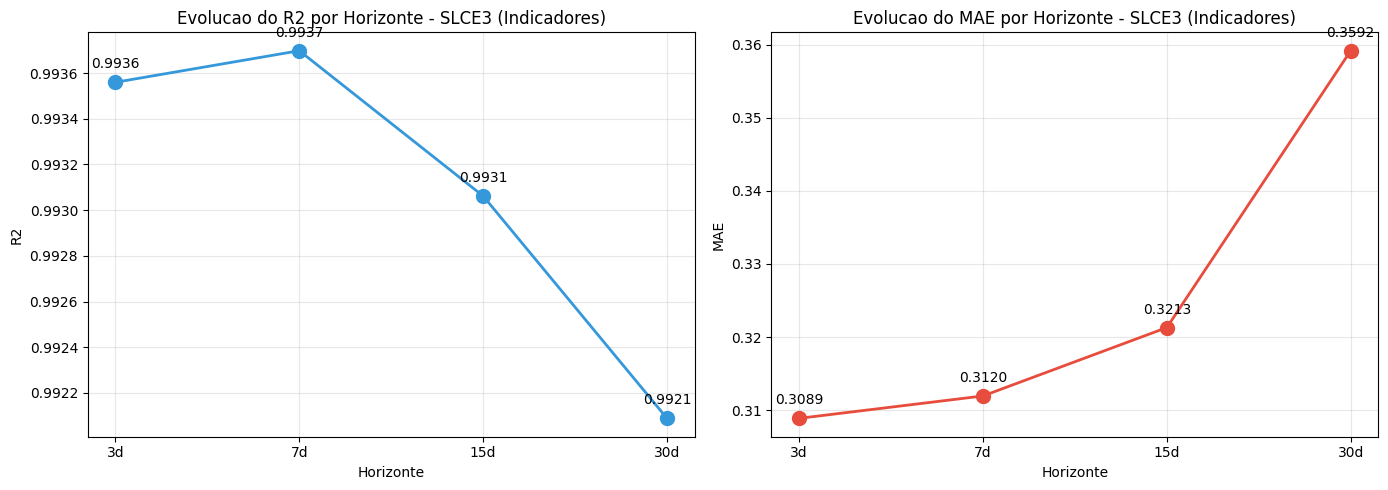

OK - Graficos de evolucao de R2 e MAE salvos


In [13]:
# Evolucao das metricas R2 e MAE por horizonte
periods = ['3d', '7d', '15d', '30d']
r2_values = [models[p]['r2'] for p in periods]
mae_values = [models[p]['mae'] for p in periods]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot R2
axes[0].plot(periods, r2_values, marker='o', linewidth=2, markersize=10, color='#3498db')
axes[0].set_title('Evolucao do R2 por Horizonte - SLCE3 (Indicadores)')
axes[0].set_xlabel('Horizonte')
axes[0].set_ylabel('R2')
axes[0].grid(True, alpha=0.3)
for i, v in enumerate(r2_values):
    axes[0].annotate(f'{v:.4f}', (periods[i], v), textcoords="offset points", xytext=(0, 10), ha='center')

# Plot MAE
axes[1].plot(periods, mae_values, marker='o', linewidth=2, markersize=10, color='#e74c3c')
axes[1].set_title('Evolucao do MAE por Horizonte - SLCE3 (Indicadores)')
axes[1].set_xlabel('Horizonte')
axes[1].set_ylabel('MAE')
axes[1].grid(True, alpha=0.3)
for i, v in enumerate(mae_values):
    axes[1].annotate(f'{v:.4f}', (periods[i], v), textcoords="offset points", xytext=(0, 10), ha='center')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}evolucao_metricas_{company_lower}_{DATASET_LABEL}.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Graficos de evolucao de R2 e MAE salvos')


### Resumo Final


In [14]:
print('\n' + '='*80)
print('RESUMO FINAL - REGRESSAO LINEAR VIA REDE NEURAL SLCE3 (DATASET INDICADORES)')
print('='*80)

print('\nMETODOLOGIA:')
print('  1. Train + Validacao (Dev): 80% dos dados')
print('  2. Teste Final (Holdout): 20% dos dados')
print('  3. Dentro do Dev: KFold (5 folds) + RandomizedSearchCV')
print('  4. Pipeline anti-leakage: SimpleImputer (mediana) + StandardScaler + MLPRegressor')
print('  5. Metrica de selecao de hiperparametros: neg_mean_absolute_error')

print('\nFEATURES UTILIZADAS:')
print(f'  - Total: {len(all_features)} features')
print(f'  - Base (OHLC): {base_features}')
print(f'  - Indicadores agro (lags): {agro_lag_features}')
print(f'  - Extras (Indicadores): {technical_indicators}')

print('\n' + '-'*80)
print('RESULTADOS POR HORIZONTE:')
print('-'*80)
periods = ['3d', '7d', '15d', '30d']
for period in periods:
    m = models[period]
    print(f"\n{period.upper()}:")
    print(f"  CV MAE (5 folds):               {m['best_cv_mae']:.4f}")
    print(f"  OOF R2:                         {m['val_r2_oof']:.4f}")
    print(f"  OOF MAE:                        {m['val_mae_oof']:.4f}")
    print(f"  Test R2:                        {m['r2']:.4f}")
    print(f"  Test MAE:                       {m['mae']:.4f}")
    print(f"  Test RMSE:                      {m['rmse']:.4f}")

print('\n' + '-'*80)
print('ARQUIVOS GERADOS:')
print('-'*80)
print(f'  - metricas_{company_lower}_{DATASET_LABEL}.csv')
print(f'  - serie_temporal_{company_lower}_{DATASET_LABEL}.png')
print(f'  - residuos_{company_lower}_{DATASET_LABEL}.png')
print(f'  - real_vs_predito_{company_lower}_{DATASET_LABEL}.png')
print(f'  - comparacao_cv_vs_teste_{company_lower}_{DATASET_LABEL}.png')
print(f'  - histograma_residuos_{company_lower}_{DATASET_LABEL}.png')
print(f'  - residuos_temporais_{company_lower}_{DATASET_LABEL}.png')
print(f'  - dispersao_ic_{company_lower}_{DATASET_LABEL}.png')
print(f'  - evolucao_metricas_{company_lower}_{DATASET_LABEL}.png')
print('='*80)



RESUMO FINAL - REGRESSAO LINEAR VIA REDE NEURAL SLCE3 (DATASET INDICADORES)

METODOLOGIA:
  1. Train + Validacao (Dev): 80% dos dados
  2. Teste Final (Holdout): 20% dos dados
  3. Dentro do Dev: KFold (5 folds) + RandomizedSearchCV
  4. Pipeline anti-leakage: SimpleImputer (mediana) + StandardScaler + MLPRegressor
  5. Metrica de selecao de hiperparametros: neg_mean_absolute_error

FEATURES UTILIZADAS:
  - Total: 19 features
  - Base (OHLC): ['Close', 'Low', 'High', 'Open']
  - Indicadores agro (lags): ['agro_cambio_close_lag_1d', 'agro_cambio_close_lag_3d', 'agro_cambio_close_lag_6d', 'agro_cambio_close_lag_10d', 'agro_soja_close_lag_1d', 'agro_soja_close_lag_3d', 'agro_soja_close_lag_6d', 'agro_soja_close_lag_10d']
  - Extras (Indicadores): ['OBV', 'FWMA', 'TEMA', 'HLC3', 'BB_upper', 'BB_middle', 'BB_lower']

--------------------------------------------------------------------------------
RESULTADOS POR HORIZONTE:
--------------------------------------------------------------------